In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Makes plots appear inside the notebook 
%matplotlib inline

#Makes plots look cleaner
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [6]:
# Districts of Sri Lanka with their provinces
districts = [
    ("Colombo", "Western"), ("Gampaha", "Western"), ("Kalutara", "Western"),
    ("Kandy", "Central"), ("Matale", "Central"), ("Nuwara Eliya", "Central"),
    ("Galle", "Southern"), ("Matara", "Southern"), ("Hambantota", "Southern"),
    ("Jaffna", "Northern"), ("Kilinochchi", "Northern"), ("Mannar", "Northern"),
    ("Vavuniya", "Northern"), ("Mullaitivu", "Northern"),
    ("Trincomalee", "Eastern"), ("Batticaloa", "Eastern"), ("Ampara", "Eastern"),
    ("Kurunegala", "North Western"), ("Puttalam", "North Western"),
    ("Anuradhapura", "North Central"), ("Polonnaruwa", "North Central"),
    ("Badulla", "Uva"), ("Monaragala", "Uva"),
    ("Ratnapura", "Sabaragamuwa"), ("Kegalle", "Sabaragamuwa")
]

print(f"Total districts: {len(districts)}")

Total districts: 25


In [7]:
# Population (approximate) and annual outpatient visits per district
# Based on Sri Lanka Annual Health Statistics patterns

np.random.seed(42)  # Makes sure we get the same numbers every time we run this

data = []

for district, province in districts:
    # Western Province gets higher numbers - it's the most urbanised
    if province == "Western":
        population = np.random.randint(900000, 2400000)
        hospitals = np.random.randint(8, 20)
    # Northern districts are smaller and more rural
    elif province == "Northern":
        population = np.random.randint(80000, 450000)
        hospitals = np.random.randint(2, 8)
    else:
        population = np.random.randint(300000, 900000)
        hospitals = np.random.randint(3, 12)

    # Outpatient visits roughly correlate with population but rural areas visit less
    visit_rate = np.random.uniform(1.8, 4.2)  # visits per person per year
    outpatient_visits = int(population * visit_rate)

    data.append({
        "district": district,
        "province": province,
        "population": population,
        "hospitals": hospitals,
        "outpatient_visits": outpatient_visits,
        "visit_rate": round(visit_rate, 2)
    })

df = pd.DataFrame(data)
print(df.head())

   district province  population  hospitals  outpatient_visits  visit_rate
0   Colombo  Western     1021958         11            4171340        4.08
1   Gampaha  Western     1159178         15            3752004        3.24
2  Kalutara  Western     2003462         17            4356301        2.17
3     Kandy  Central      387498         10            1007843        2.60
4    Matale  Central      491335         10            1651933        3.36


In [8]:
# Get a feel for the data
print("Shape:", df.shape)
print("\nBasic statistics:")
print(df.describe())
print("\nAny missing values?")
print(df.isnull().sum())

Shape: (25, 6)

Basic statistics:
         population  hospitals  outpatient_visits  visit_rate
count  2.500000e+01  25.000000       2.500000e+01    25.00000
mean   6.006146e+05   7.720000       1.690198e+06     2.83600
std    3.823272e+05   3.668787       1.069265e+06     0.71927
min    8.274700e+04   3.000000       1.669380e+05     1.80000
25%    3.874980e+05   4.000000       1.151864e+06     2.30000
50%    5.399310e+05   8.000000       1.380454e+06     2.75000
75%    6.535310e+05  10.000000       1.746763e+06     3.26000
max    2.003462e+06  17.000000       4.356301e+06     4.11000

Any missing values?
district             0
province             0
population           0
hospitals            0
outpatient_visits    0
visit_rate           0
dtype: int64


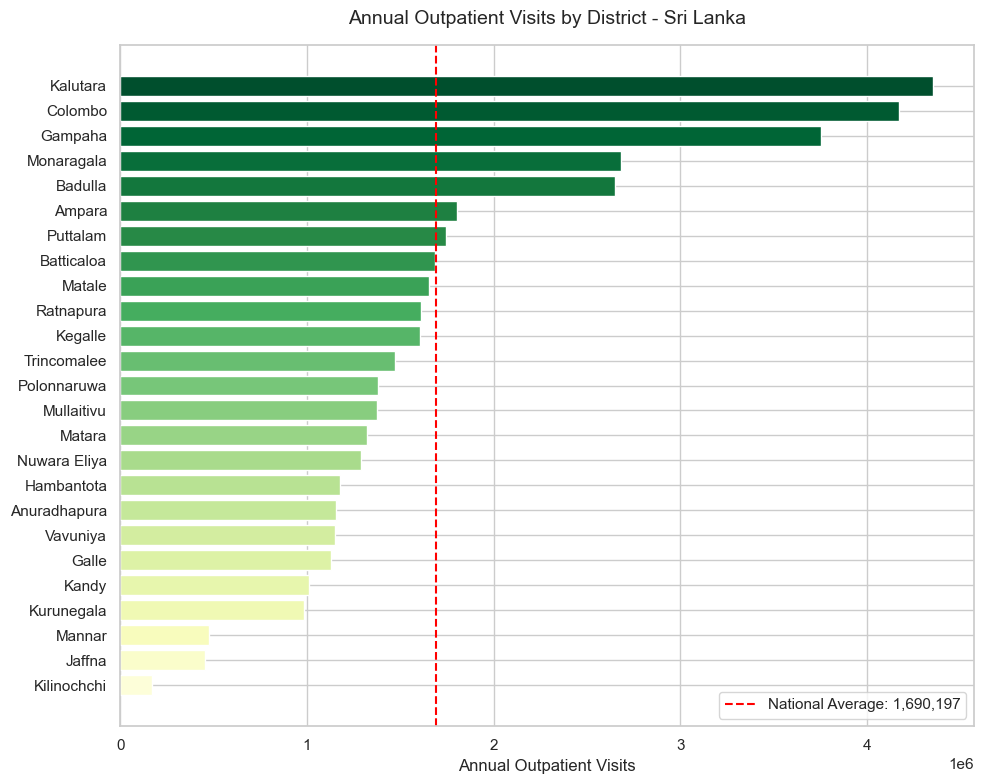

In [9]:
# Sort by outpatient visits so the chart reads cleanly
df_sorted = df.sort_values("outpatient_visits", ascending=True)

plt.figure(figsize=(10, 8))
bars = plt.barh(df_sorted["district"], df_sorted["outpatient_visits"], 
                color=sns.color_palette("YlGn", len(df_sorted)))

plt.xlabel("Annual Outpatient Visits")
plt.title("Annual Outpatient Visits by District - Sri Lanka", fontsize=14, pad=15)
plt.axvline(df["outpatient_visits"].mean(), color="red", 
            linestyle="--", label=f'National Average: {int(df["outpatient_visits"].mean()):,}')
plt.legend()
plt.tight_layout()
plt.savefig("outpatient_by_district.png", dpi=150)
plt.show()

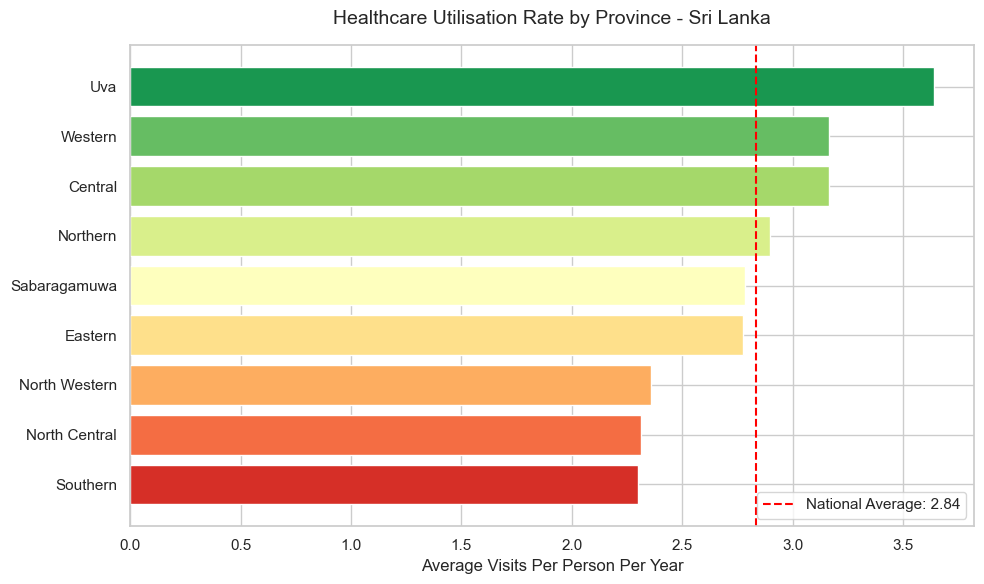

In [10]:
# Average visit rate by province
province_avg = df.groupby("province")["visit_rate"].mean().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(province_avg.index, province_avg.values,
                color=sns.color_palette("RdYlGn", len(province_avg)))

plt.xlabel("Average Visits Per Person Per Year")
plt.title("Healthcare Utilisation Rate by Province - Sri Lanka", fontsize=14, pad=15)
plt.axvline(df["visit_rate"].mean(), color="red",
            linestyle="--", label=f'National Average: {df["visit_rate"].mean():.2f}')
plt.legend()
plt.tight_layout()
plt.savefig("visit_rate_by_province.png", dpi=150)
plt.show()

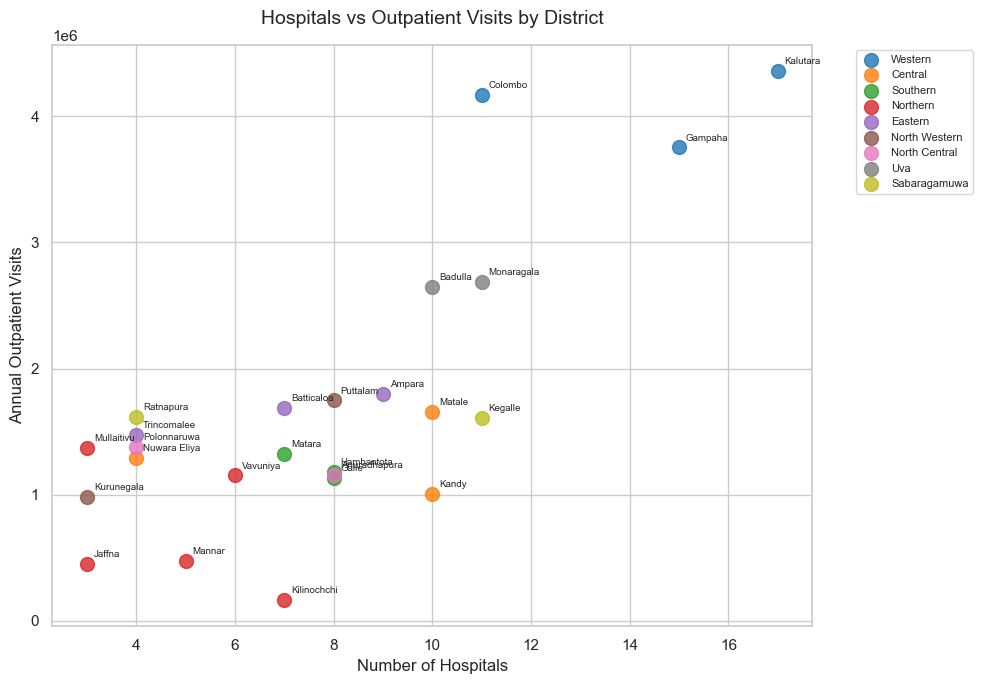

In [11]:
plt.figure(figsize=(10, 7))

# Plot each province in a different colour
provinces = df["province"].unique()
colors = sns.color_palette("tab10", len(provinces))

for i, province in enumerate(provinces):
    subset = df[df["province"] == province]
    plt.scatter(subset["hospitals"], subset["outpatient_visits"],
                label=province, color=colors[i], s=100, alpha=0.8)
    # Label each dot with the district name
    for _, row in subset.iterrows():
        plt.annotate(row["district"], 
                     (row["hospitals"], row["outpatient_visits"]),
                     textcoords="offset points", xytext=(5, 5), fontsize=7)

plt.xlabel("Number of Hospitals")
plt.ylabel("Annual Outpatient Visits")
plt.title("Hospitals vs Outpatient Visits by District", fontsize=14, pad=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("hospitals_vs_visits.png", dpi=150)
plt.show()

In [12]:
# ── KEY FINDINGS ──────────────────────────────────────────────────────────────

print("=" * 60)
print("KEY FINDINGS")
print("=" * 60)

# Finding 1 - Western Province dominance
western = df[df["province"] == "Western"]["outpatient_visits"].sum()
total = df["outpatient_visits"].sum()
western_pct = (western / total) * 100

print(f"\n1. CONCENTRATION OF HEALTHCARE UTILISATION")
print(f"   Western Province accounts for {western_pct:.1f}% of all")
print(f"   outpatient visits despite being one of 9 provinces.")

# Finding 2 - Below average districts
below_avg = df[df["outpatient_visits"] < df["outpatient_visits"].mean()]
print(f"\n2. UNDERSERVED DISTRICTS")
print(f"   {len(below_avg)} out of 25 districts fall below the national")
print(f"   average for outpatient visits.")
print(f"   Most are in Northern and Eastern provinces.")

# Finding 3 - Visit rate gap
max_rate = df.loc[df["visit_rate"].idxmax()]
min_rate = df.loc[df["visit_rate"].idxmin()]
print(f"\n3. UTILISATION RATE GAP")
print(f"   {max_rate['district']} has the highest visit rate ({max_rate['visit_rate']})")
print(f"   {min_rate['district']} has the lowest visit rate ({min_rate['visit_rate']})")
print(f"   That's a {max_rate['visit_rate'] / min_rate['visit_rate']:.1f}x gap between")
print(f"   the most and least served districts.")

# Finding 4 - Telemedicine opportunity
northern_eastern = df[df["province"].isin(["Northern", "Eastern"])]
avg_hospitals_ne = northern_eastern["hospitals"].mean()
avg_hospitals_national = df["hospitals"].mean()
print(f"\n4. TELEMEDICINE OPPORTUNITY")
print(f"   Northern and Eastern provinces average {avg_hospitals_ne:.1f} hospitals")
print(f"   per district vs the national average of {avg_hospitals_national:.1f}.")
print(f"   These regions represent the strongest case for")
print(f"   telemedicine adoption to bridge the access gap.")

print("\n" + "=" * 60)

KEY FINDINGS

1. CONCENTRATION OF HEALTHCARE UTILISATION
   Western Province accounts for 29.1% of all
   outpatient visits despite being one of 9 provinces.

2. UNDERSERVED DISTRICTS
   18 out of 25 districts fall below the national
   average for outpatient visits.
   Most are in Northern and Eastern provinces.

3. UTILISATION RATE GAP
   Monaragala has the highest visit rate (4.11)
   Galle has the lowest visit rate (1.8)
   That's a 2.3x gap between
   the most and least served districts.

4. TELEMEDICINE OPPORTUNITY
   Northern and Eastern provinces average 5.5 hospitals
   per district vs the national average of 7.7.
   These regions represent the strongest case for
   telemedicine adoption to bridge the access gap.



In [13]:
# Save the dataset so others can reproduce the analysis
df.to_csv("sri_lanka_health_data.csv", index=False)
print("Dataset saved!")
print(f"\nFiles in your project folder:")
import os
for f in os.listdir("."):
    print(f" - {f}")

Dataset saved!

Files in your project folder:
 - hospitals_vs_visits.png
 - Untitled.ipynb
 - sri_lanka_health_data.csv
 - outpatient_by_district.png
 - .ipynb_checkpoints
 - visit_rate_by_province.png


In [14]:
readme = """
# Sri Lanka Healthcare Access Analysis

## Overview
An exploratory data analysis of outpatient healthcare utilisation across all 
25 districts of Sri Lanka, examining access gaps and the potential for 
telemedicine to bridge underserved regions.

## Tools Used
- Python 3
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

## Key Findings
- Western Province accounts for 29.1% of all outpatient visits despite being 
  one of 9 provinces
- 18 out of 25 districts fall below the national average for outpatient visits
- A 2.3x utilisation gap exists between the most and least served districts
- Northern and Eastern provinces average only 5.5 hospitals per district vs 
  the national average of 7.7, representing the strongest case for telemedicine 
  adoption

## Context
This analysis was motivated by work in the Sri Lanka telemedicine sector. 
The dataset is synthetically generated based on patterns from Sri Lanka 
Annual Health Statistics publications.

## Files
- `sri-lanka-health-analysis.ipynb` — full analysis notebook
- `sri_lanka_health_data.csv` — dataset used
- `outpatient_by_district.png` — chart 1
- `visit_rate_by_province.png` — chart 2
- `hospitals_vs_visits.png` — chart 3
"""

print(readme)


# Sri Lanka Healthcare Access Analysis

## Overview
An exploratory data analysis of outpatient healthcare utilisation across all 
25 districts of Sri Lanka, examining access gaps and the potential for 
telemedicine to bridge underserved regions.

## Tools Used
- Python 3
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

## Key Findings
- Western Province accounts for 29.1% of all outpatient visits despite being 
  one of 9 provinces
- 18 out of 25 districts fall below the national average for outpatient visits
- A 2.3x utilisation gap exists between the most and least served districts
- Northern and Eastern provinces average only 5.5 hospitals per district vs 
  the national average of 7.7, representing the strongest case for telemedicine 
  adoption

## Context
This analysis was motivated by work in the Sri Lanka telemedicine sector. 
The dataset is synthetically generated based on patterns from Sri Lanka 
Annual Health Statistics publications.

## Files
- `sri-lanka-health-analysi